In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FormatStrFormatter

from pbhstat.power_spectrum import PowerSpectrum
from pbhstat.mass_variance import MassVariance
from pbhstat.collapse_stats import PressSchechterModel, PeaksTheoryModel, NonLinearModel
from pbhstat.mass_function import MassFunction
from pbhstat.plot_utils import plot_power_spectrum, plot_mass_variance, plot_mass_function, bounds_utility

In [35]:
# Set up k values
k_values = np.logspace(5, 7, 3000)

# Piecewise power spectrum
ps_piecewise = PowerSpectrum(
    shape='piecewise',
    amplitude=0.018,
    k_star=1e6,
    ng=2,
    nd=2,
    k_values=k_values
)


# Instantiate mass variance with choice of window function and statistics
mv_piecewise = MassVariance(window='realtophat', power_spectrum=ps_piecewise, statistics='press', cutoff=True)

# Instantiate mass function with same statistics model
mass_function = MassFunction(mass_variance=mv_piecewise, statistics='press', K=4, g_c=0.77, gamma=0.36)

# non-linear statistics example
#mv_piecewise = MassVariance(window='realtophat', power_spectrum=ps_piecewise, statistics='nonlinear', cutoff=False)
#mass_function = MassFunction(mass_variance=mv_piecewise, statistics='nonlinear', K=4, vcorr=True, gamma=0.36)

In [36]:
# Evaluate f(M) and f_PBH
m, f_m = mass_function.evaluate(k_values, mpbh_vals=50)

fpbh = mass_function.fpbh(f_m, m)

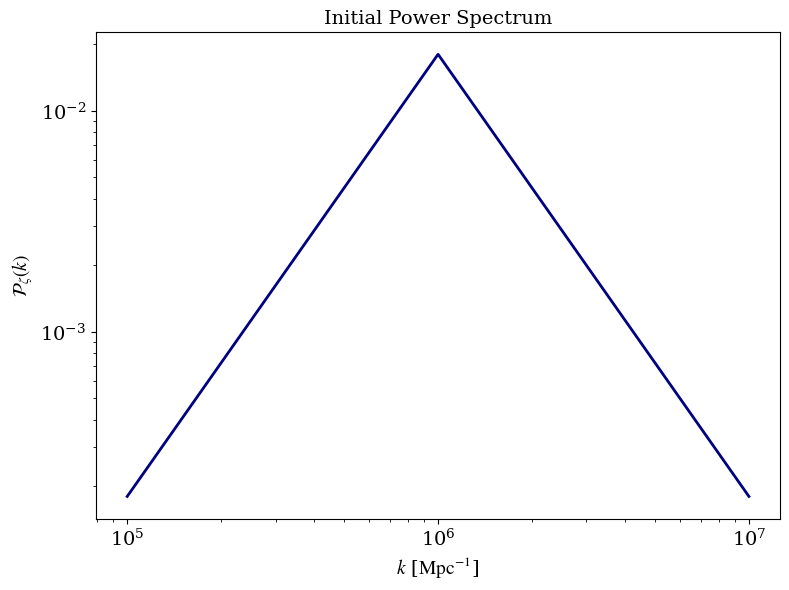

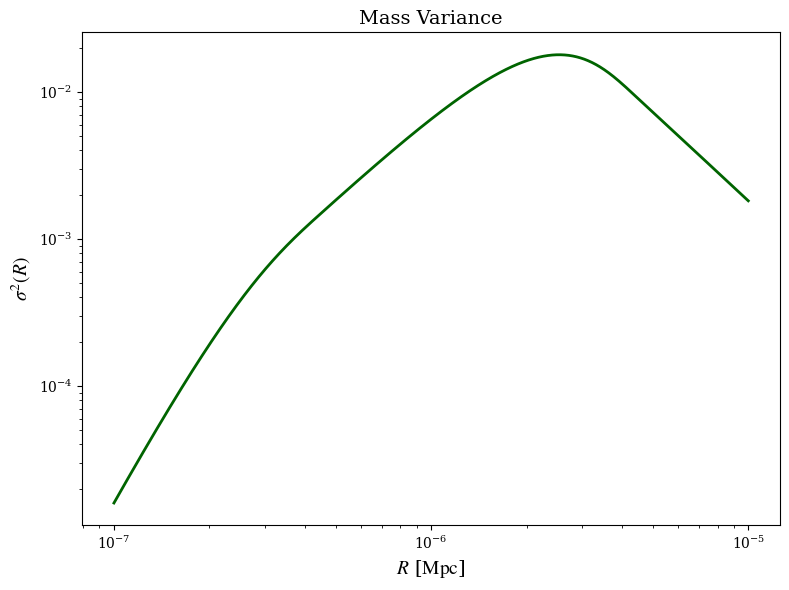

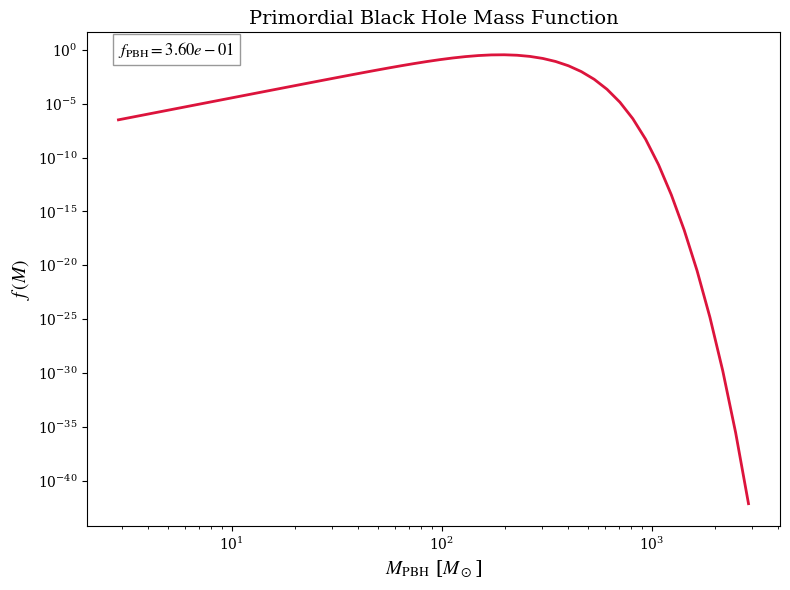

In [37]:
# Plot power spectrum

plot_power_spectrum(k_values, ps_piecewise(k_values))

# Plot mass variance

# Define R values
R_values = 1/k_values

# Evaluate mass variance at k_values
sigma_piecewise = mv_piecewise.evaluate(k_values)

plot_mass_variance(R_values, sigma_piecewise)

# Plot mass function

plot_mass_function(m, f_m, fpbh_val=fpbh)

In [ ]:
bounds_utility(m, f_m, 'path_to_PBHbounds')